# Model Camparison
This notebook compares the three trained models  for autonomous driving obstacle detection:
- ResNet18
- MobileNetV3-Small
- EfficientNet-B0

The comparison is based on the training history,vlaidation performance, and model complexity 

In [1]:
# Imports
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
!git clone https://github.com/gracyy-rm/autonomous-binary-classifier.git

Cloning into 'autonomous-binary-classifier'...
remote: Enumerating objects: 537, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 537 (delta 19), reused 25 (delta 9), pack-reused 498 (from 2)
Receiving objects: 100% (537/537), 268.99 MiB | 39.48 MiB/s, done.
Resolving deltas: 100% (288/288), done.
Updating files: 100% (60/60), done.


In [27]:
os.chdir("/kaggle/working/autonomous-binary-classifier")

In [28]:
from src.model import create_model

## Load Experiment Results
Tthe training aritifacts generated during model training are loaded from thier respective directories.

In [11]:
EXPERIMENTS_DIR = "/kaggle/input/datasets/gracyyadav79/experiments-models"
experiment_paths = {
    "ResNet18" :  os.path.join(EXPERIMENTS_DIR, "resnet18_experiment","resnet18_lr0.001_bs128_20260810_052851"),
    "MobileNetV3-Small" : os.path.join(EXPERIMENTS_DIR, "mobilenet_experiment","mobilenet_v3_lr0.001_bs128_20260810_085636"),
    "EfficientNet_B0" : os.path.join(EXPERIMENTS_DIR, "efficientnet_experiment","efficientnet_b0_lr0.001_bs128_20260810_071818")
}

In [12]:
experiments = {}

for model_name, experiment_path in experiment_paths.items():
    with open(os.path.join(experiment_path, "history.json")) as f:
        history = json.load(f)

    with open(os.path.join(experiment_path, "summary.json")) as f:
        summary = json.load(f)

    with open(os.path.join(experiment_path, "config.json")) as f:
        config = json.load(f)

    experiments[model_name] = {
        "history": history,
        "summary": summary,
        "config": config
    }

print("Loaded experiments:")
for model_name in experiments:
    print(f"- {model_name}")

Loaded experiments:
- ResNet18
- MobileNetV3-Small
- EfficientNet_B0


In [14]:
# verify the loaded experiments
for model_name,experiment in experiments.items():
    summary = experiment["summary"]
    print(
        f"{model_name}: "
        f"Best Val Acc = {summary['best_val_acc'] * 100:.2f}% | "
        f"Best Epoch = {summary['best_epoch']}"
    )

ResNet18: Best Val Acc = 91.20% | Best Epoch = 8
MobileNetV3-Small: Best Val Acc = 91.29% | Best Epoch = 10
EfficientNet_B0: Best Val Acc = 91.48% | Best Epoch = 3


## Training Curves
Training and validation loss and accuracy are compared across all three models to analyze convergence and generalization.

#### Loss Curve

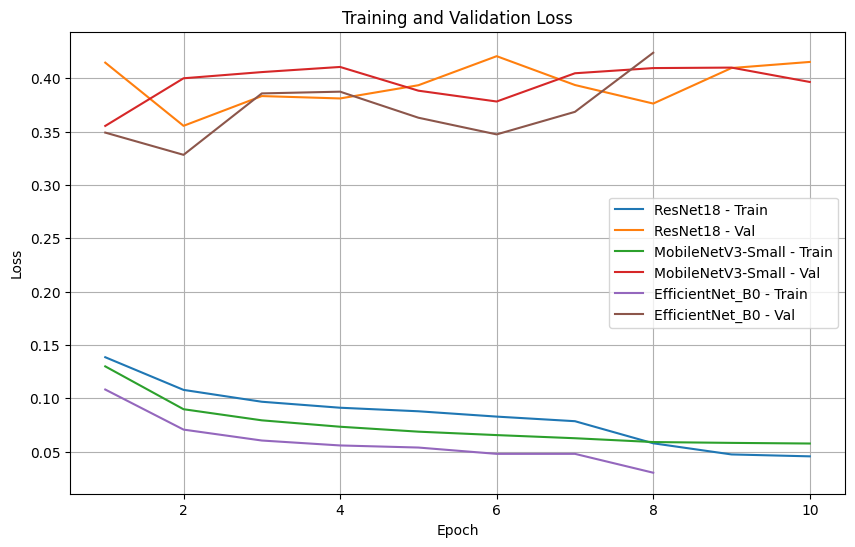

In [15]:
plt.figure(figsize=(10,6))

for model_name,experiment in experiments.items():
    history = experiment["history"]
    plt.plot(history["epoch"],history["train_loss"],label=f"{model_name} - Train")
    plt.plot(history["epoch"],history["val_loss"],label=f"{model_name} - Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

#### Accuracy Curve

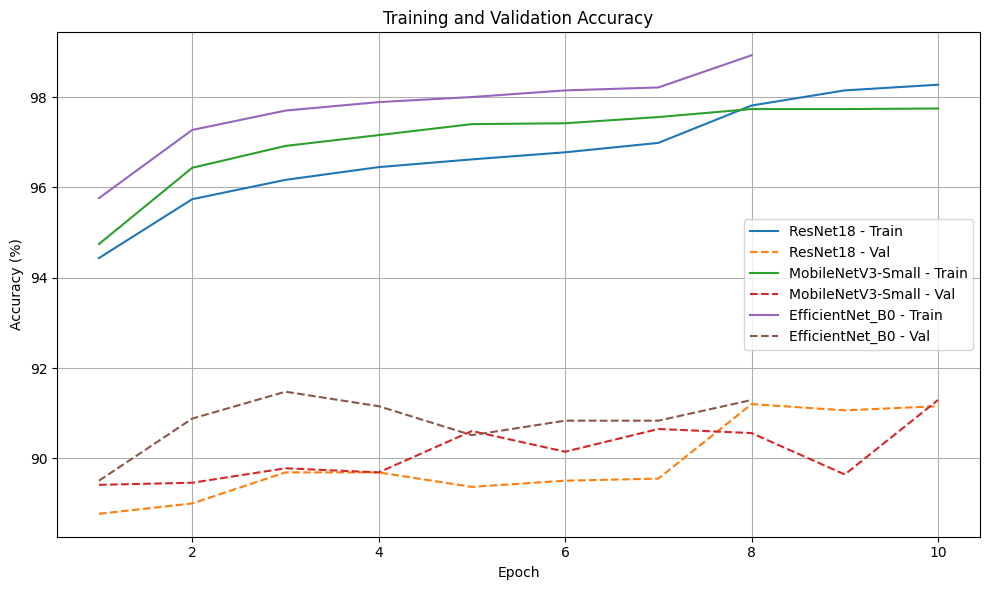

In [18]:
plt.figure(figsize=(10, 6))

for model_name, experiment in experiments.items():
    history = experiment["history"]

    plt.plot(history["epoch"], [acc * 100 for acc in history["train_acc"]], label=f"{model_name} - Train")
    plt.plot(history["epoch"], [acc * 100 for acc in history["val_acc"]], "--", label=f"{model_name} - Val")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Performance Comparison
The best validation performance of each model is summarized using the metrics records during training

In [21]:
comparison = []

for model_name, experiment in experiments.items():
    summary = experiment["summary"]

    comparison.append({
        "Model": model_name,
        "Best Epoch": summary["best_epoch"],
        "Best Validation Accuracy (%)": summary["best_val_acc"] * 100,
        "Best Validation Loss": summary["best_val_loss"],
        "Total Epochs": summary["total_epochs_completed"]
    })

comparison_df = pd.DataFrame(comparison)

comparison_df = comparison_df.sort_values(
    "Best Validation Accuracy (%)",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Best Epoch,Best Validation Accuracy (%),Best Validation Loss,Total Epochs
0,EfficientNet_B0,3,91.475710,0.385909,8
1,MobileNetV3-Small,10,91.292392,0.396626,10
2,ResNet18,8,91.200733,0.376390,10


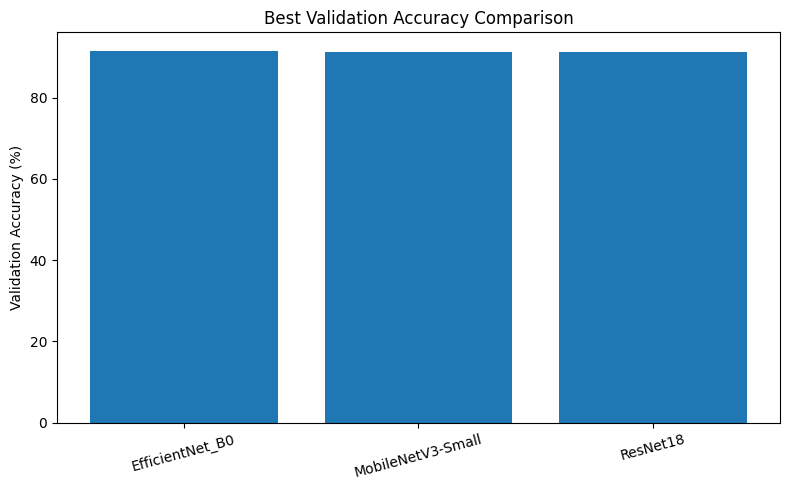

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Best Validation Accuracy (%)"]
)

plt.ylabel("Validation Accuracy (%)")
plt.title("Best Validation Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Validation Metrics Comparison

The models are compared using validation accuracy, precision, recall, F1-score, and validation loss to evaluate their overall classification performance.

In [23]:
metrics_comparison = []

for model_name, experiment in experiments.items():
    history = experiment["history"]

    best_idx = history["val_acc"].index(max(history["val_acc"]))

    metrics_comparison.append({
        "Model": model_name,
        "Val Accuracy (%)": history["val_acc"][best_idx] * 100,
        "Val Precision": history["val_precision"][best_idx],
        "Val Recall": history["val_recall"][best_idx],
        "Val F1": history["val_f1"][best_idx],
        "Val Loss": history["val_loss"][best_idx],
        "Best Epoch": history["epoch"][best_idx]
    })

metrics_df = pd.DataFrame(metrics_comparison)
metrics_df = metrics_df.sort_values("Val F1", ascending=False).reset_index(drop=True)

metrics_df

,Model,Val Accuracy (%),Val Precision,Val Recall,Val F1,Val Loss,Best Epoch
0,EfficientNet_B0,91.475710,0.929758,0.929758,0.929758,0.385909,3
1,MobileNetV3-Small,91.292392,0.924401,0.932779,0.928571,0.396626,10
2,ResNet18,91.200733,0.921131,0.935045,0.928036,0.376390,8


## Model Complexity

Model size and parameteer count are compared to understand the trade off between predictive performance and computational complexity.

In [29]:
complexity = []

for model_name, experiment in experiments.items():
    config = experiment["config"]
    model = create_model(
        model_name=config["model"]["architecture"],
        num_classes=1,
        freeze_backbone=config["model"]["freeze_backbone"]
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    model_size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 ** 2)

    complexity.append({
        "Model": model_name,
        "Total Parameters (M)": total_params / 1e6,
        "Trainable Parameters (M)": trainable_params / 1e6,
        "Model Size (MB)": model_size_mb
    })

complexity_df = pd.DataFrame(complexity)
complexity_df

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s] 


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 103MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s]


,Model,Total Parameters (M),Trainable Parameters (M),Model Size (MB)
0,ResNet18,11.308097,11.308097,43.136967
1,MobileNetV3-Small,1.074977,1.074977,4.100712
2,EfficientNet_B0,4.335741,4.335741,16.539539


**Visualization**

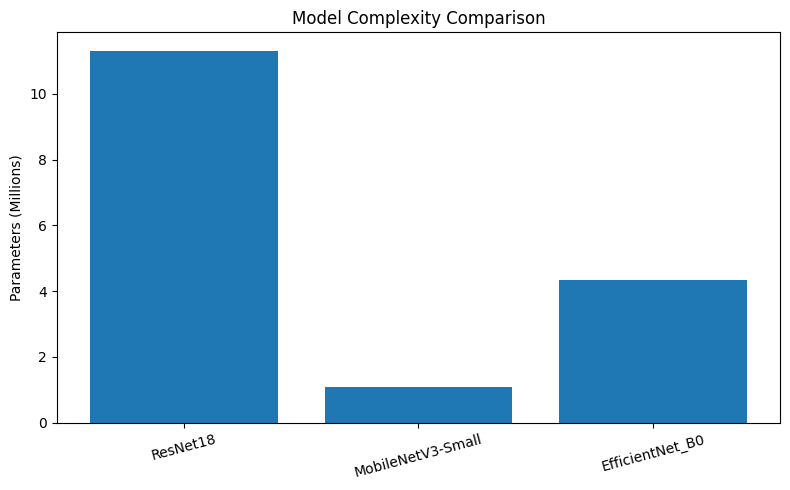

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(
    complexity_df["Model"],
    complexity_df["Total Parameters (M)"]
)

plt.ylabel("Parameters (Millions)")
plt.title("Model Complexity Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Final Model Selection
The final model is selected based on validation performance, generalization behavior, and model complexity

In [31]:
final_comparison = metrics_df.merge(
    complexity_df,
    on="Model"
)

final_comparison = final_comparison.sort_values(
    "Val F1",
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,Val Accuracy (%),Val Precision,Val Recall,Val F1,Val Loss,Best Epoch,Total Parameters (M),Trainable Parameters (M),Model Size (MB)
0,EfficientNet_B0,91.475710,0.929758,0.929758,0.929758,0.385909,3,4.335741,4.335741,16.539539
1,MobileNetV3-Small,91.292392,0.924401,0.932779,0.928571,0.396626,10,1.074977,1.074977,4.100712
2,ResNet18,91.200733,0.921131,0.935045,0.928036,0.376390,8,11.308097,11.308097,43.136967


### Selection Criteria

The final model is selected using the following criteria:

1. Validation performance
2. Precision and recall for obstacle detection
3. F1-Score
4. Generalization behavior
5. Model complexity

## Final Model Selection

**EfficientNet-B0 was selected as the final model based on its overall balance between predictive performance and model complexity. It achieved the highest validation accuracy (91.48%) and F1-score (0.930) among the three models while using only 4.34M parameters and approximately 16.54 MB of storage. Although MobileNetV3-Small provides a substantially smaller model and ResNet18 achieves slightly higher recall, EfficientNet-B0 provides the strongest overall performance-complexity trade-off for this project.**

### Selected Model

- Based on the quantitative comparison, **[EfficientNet_B0]** is selected as the primary candidate for further evaluation.
- The selected model is subsequently analyzed using inference and Grad-CAM to evaluate its predictions and visual explanations.